# 04 · The whole curve → an image → a CNN

*A first neural network — and a lesson in choosing the right input.*

> ⏱ **Runtime:** ~15 s on a laptop CPU (no GPU) · 🎓 **Level:** beginner · 📊 **Data:** AFM grid (load–depth curves)

### 🎯 What you'll learn
1. how a 1-D **load–depth curve** becomes a 2-D **GAF image**,
2. what a **CNN** (convolutional neural network) is, built small in PyTorch on CPU,
3. a crucial lesson: the **GAF is scale-invariant** — it sees *shape*, not size,
4. so you must **match the representation to what actually separates your classes**.

### 🧭 What you need to know first
- Notebooks **01–03** (features, a classifier, train/test split).
- Comfort with the idea of a load–depth curve (notebook 00).

> 🧠 **What's a CNN, in one breath?** A **convolutional neural network** is a model that
> slides small learnable filters over an image to detect patterns (edges, blobs, textures),
> stacks them into ever-more-abstract features, and ends in a classifier. It is the standard
> tool for images — so first we *turn each curve into an image*.
>
> Data is public/own only. Task: hard vs soft phase on the AFM grid (labels from hardness,
> used only as ground truth to score against).

### Step 0 — set-up

Run the cell below first. In Jupyter you run a cell by clicking it and pressing **Shift + Enter**.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py` — that means the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
# Confirm the helpers loaded (just the tail of the path, not your machine's folders).
_pkg = os.path.basename(os.path.dirname(mm.__file__))
print("helpers loaded from: .../" + _pkg + "/" + os.path.basename(mm.__file__))

helpers loaded from: .../mecanano_ml/__init__.py


> 🧠 **PyTorch** — a popular library for building and training neural networks. Everything here runs on the CPU in seconds — no GPU needed.

> 🧠 **tensor** — PyTorch's name for a multi-dimensional array (like a NumPy array) that a network can compute with.

In [2]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix
torch.manual_seed(0); np.random.seed(0)          # fixed seeds -> repeatable training

## 1 · Curves and labels

The input is each indent's **load–depth curve** (64 numbers). The label is simply hard vs
soft phase, split at the median hardness.

> ✅ **When you run the next cell, you should see:** the number of curves kept and the hard/soft counts (roughly balanced).

In [3]:
afm = mm.load_afm_grid()
Craw = afm["load_mN"].copy()                     # (n, 64): load vs depth for each indent
keep = np.isfinite(Craw).mean(0) > 0.5           # keep depth points present in most curves
Craw = SimpleImputer(strategy="median").fit_transform(Craw[:, keep])
ok = Craw.std(1) > 1e-6                           # drop flat / dead curves
Craw = Craw[ok]
y = (afm["H"][ok] > np.median(afm["H"][ok])).astype(int)   # 1 = hard, 0 = soft
print("curves:", Craw.shape, " hard/soft:", int(y.sum()), int((1 - y).sum()))

curves: (828, 64)  hard/soft: 414 414


## 2 · Curve → GAF image

A **Gramian Angular Field (GAF)** turns a 1-D sequence into a square image that encodes the
curve's values and how they relate across depth — something a CNN can convolve over.

> 🧠 **Gramian Angular Field (GAF)** — an image built from a 1-D curve: it first rescales the curve to [−1, 1], then encodes the angle relationships between every pair of points as pixels. Similar shapes → similar images.

> ✅ **When you run the next cell, you should see:** three panels: two example curves (soft, hard), and their GAF images. The two images look different — the CNN will learn to tell them apart.

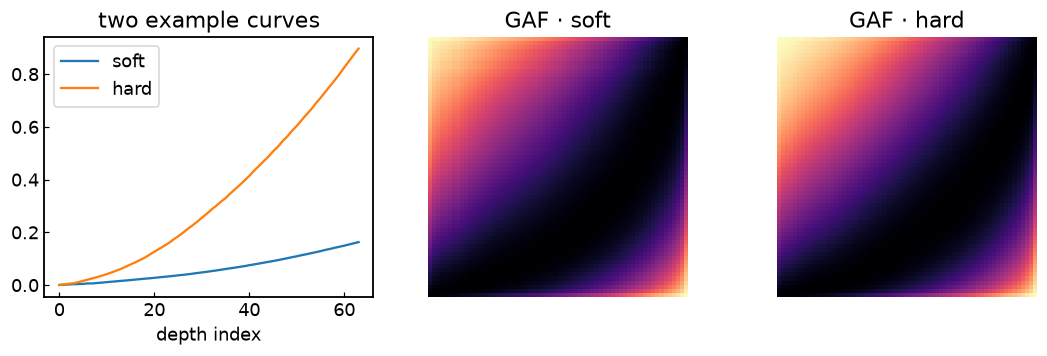

In [4]:
from pyts.image import GramianAngularField
gaf = GramianAngularField(image_size=Craw.shape[1], method="summation")
imgs = gaf.fit_transform(Craw)                   # (n, L, L) images in [-1, 1]

fig, ax = plt.subplots(1, 3, figsize=(10, 3.4))
ax[0].plot(Craw[np.where(y == 0)[0][0]], label="soft")
ax[0].plot(Craw[np.where(y == 1)[0][0]], label="hard")
ax[0].legend(); ax[0].set_title("two example curves"); ax[0].set_xlabel("depth index")
ax[1].imshow(imgs[np.where(y == 0)[0][0]], cmap="magma"); ax[1].set_title("GAF · soft"); ax[1].axis("off")
ax[2].imshow(imgs[np.where(y == 1)[0][0]], cmap="magma"); ax[2].set_title("GAF · hard"); ax[2].axis("off")
fig.tight_layout()

*🖼 **Figure.** Left: the raw curves. Middle/right: the same curves as GAF images. The CNN never sees the line plot — it learns from the image texture.*

### ⚠️ The catch: the GAF is **scale-invariant**

Because the GAF rescales every curve to [−1, 1] first, a curve and *the same curve shifted and
doubled* produce an **identical** image. The GAF captures **shape**, and deliberately throws
away **magnitude**. Let's prove it.

> 🧠 **scale-invariance** — the property that multiplying or shifting the input leaves the output unchanged. Great when only shape matters — bad when the size of the signal is the very thing that separates your classes.

> ✅ **When you run the next cell, you should see:** a printed difference of essentially **0** between the GAF of a curve and the GAF of that curve doubled and shifted — literally the same image.

In [5]:
g1 = gaf.transform(Craw[:1])                     # GAF of one curve
g2 = gaf.transform(2 * Craw[:1] + 3)             # GAF of the SAME curve, doubled and shifted up
print("max |GAF(x) - GAF(2x+3)| =", round(float(np.abs(g1 - g2).max()), 6), " -> the same image")

max |GAF(x) - GAF(2x+3)| = 1e-06  -> the same image


## 3 · A small CNN

Two convolution blocks and a small linear head — a few thousand parameters, trained on the CPU
in seconds.

> 🧠 **epoch** — one full pass of the training data through the network. We do 25 short passes; each nudges the filters to make fewer mistakes.

> 🧠 **DataLoader** — a PyTorch helper that serves the data to the network in small batches during training.

> ✅ **When you run the next cell, you should see:** the parameter count of the network (a few thousand) — tiny by modern standards.

In [6]:
Xtr, Xte, ytr, yte = train_test_split(imgs, y, test_size=0.3, stratify=y, random_state=0)

def loader(X, yy, bs=32, shuffle=False):
    # add a channel dimension (X[:,None]) because Conv2d expects (batch, channels, H, W)
    t = TensorDataset(torch.tensor(X[:, None], dtype=torch.float32),
                      torch.tensor(yy, dtype=torch.long))
    return DataLoader(t, batch_size=bs, shuffle=shuffle)

L = imgs.shape[1]
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # two conv+pool blocks extract image features:
        self.f = nn.Sequential(nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                               nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        # then a classifier head maps features -> 2 phase scores:
        self.c = nn.Sequential(nn.Flatten(), nn.Linear(16 * (L // 4) * (L // 4), 32),
                               nn.ReLU(), nn.Linear(32, 2))
    def forward(self, x): return self.c(self.f(x))

net = SmallCNN(); opt = torch.optim.Adam(net.parameters(), 1e-3); lossf = nn.CrossEntropyLoss()
print("parameters:", sum(p.numel() for p in net.parameters()))

parameters: 132418


> ✅ **When you run the next cell, you should see:** after training, a CNN test accuracy around **0.70**. Hold that number — we compare it next.

In [7]:
tr, te = loader(Xtr, ytr, shuffle=True), loader(Xte, yte)
for epoch in range(25):                          # 25 quick passes over the data
    net.train()
    for xb, yb in tr:
        opt.zero_grad()                          # reset gradients
        lossf(net(xb), yb).backward()            # measure error, back-propagate
        opt.step()                               # nudge the weights to do better
net.eval()
with torch.no_grad():                            # no gradients needed for evaluation
    pred = torch.cat([net(xb).argmax(1) for xb, _ in te]).numpy()
acc_cnn = accuracy_score(yte, pred)
print("CNN (image route, shape only) test accuracy:", round(acc_cnn, 3))

CNN (image route, shape only) test accuracy: 0.719


## 4 · The feature route (PCA → Random Forest)

Now the **same curves**, but kept as raw vectors so **absolute scale is preserved**. Watch the
accuracy gap — this is the whole point of the notebook.

> ✅ **When you run the next cell, you should see:** the two accuracies side by side: **CNN ≈ 0.70** vs **PCA+RF ≈ 0.90**, and the CNN's confusion matrix.

CNN (GAF, shape)         : 0.719
PCA+RF (raw, keeps scale): 0.904


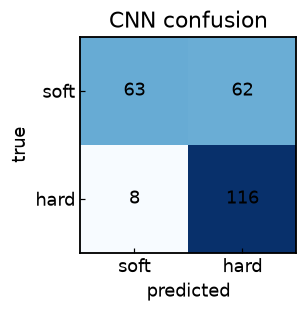

In [8]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

Ftr, Fte, gtr, gte = train_test_split(Craw, y, test_size=0.3, stratify=y, random_state=0)
# keep raw curves -> standardise -> 6 PCs -> random forest
feat = make_pipeline(StandardScaler(), PCA(6),
                     RandomForestClassifier(200, random_state=0)).fit(Ftr, gtr)
acc_feat = accuracy_score(gte, feat.predict(Fte))
print(f"CNN (GAF, shape)         : {acc_cnn:.3f}")
print(f"PCA+RF (raw, keeps scale): {acc_feat:.3f}")

fig, ax = plt.subplots(figsize=(3.3, 3))
cm = confusion_matrix(yte, pred); im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], ["soft", "hard"]); ax.set_yticks([0, 1], ["soft", "hard"])
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("CNN confusion")
for (i, j), v in np.ndenumerate(cm): ax.text(j, i, f"{v}", ha="center", va="center")
fig.tight_layout()

*🖼 **Figure.** The simpler PCA+RF beats the fancy CNN here — because these two phases differ mostly in the *level* of the curve, and the GAF threw that level away. The lesson is not 'CNNs are bad'; it's 'match the input to the task'.*

## ✅ Recap
- A **GAF** turns each curve into an image so a **CNN** can read the whole response.
- But the GAF is **scale-invariant**: it captures **shape**, not magnitude. Here the phases differ mostly in *level*, so the **feature route that keeps scale wins**.
- **Practical rule:** try both routes — use GAF/CNN when *shape* discriminates, and keep scalar features (or a 1-D CNN on the raw curve, notebook 04a) when *magnitude* matters.

## 🔧 Try it yourself
Small changes teach the most. Try these (re-run the cell after each):
1. Increase training to `range(50)` epochs. Does CNN accuracy climb much, or has it plateaued (a sign the *representation*, not training, is the limit)?
2. Swap the GAF `method="summation"` for `"difference"` and re-run. Do the images and accuracy change?
3. Give the feature route more components — `PCA(12)` instead of `PCA(6)`. Better, worse, or the same?

## 🩹 Common errors & fixes
- **`ModuleNotFoundError: pyts` / `torch`** → `pip install pyts torch` (CPU build is fine).
- **Training feels slow** → reduce epochs, or batch size `bs`. On CPU this notebook is still seconds.
- **Accuracy varies a little run-to-run** → neural nets have randomness; the *conclusion* (feature route wins here) is stable.

---
**Next:** open **`05_autoencoder_latent_space.ipynb`** — let a network learn its own compact 'coordinates' for curves.